# Using Historical Twitter Archive

### Scope

* It is possible to use social media and other media data searching for mentionds relevant to the OSCARS etc, as a proxy for public interest/engagement over time. You can use this as timeline to anchor and provide interpretation for patterns you discover in the award and other datasets you are working on.


### Background
* Between 2012 and 2022 a daily sample of 1% of Tweets posted to Twitter was collected by ASC and Wharton
* See https://research-it.wharton.upenn.edu/data/tweet-database/



---

### Purpose

* This notebook shows some steps for working with one kind of export from this data.

* The SQL query run was:
  ```

    SELECT year,
         month,
         day,
         CONCAT(month, '/', day, '/', year) AS date, 
         count(*) count
    FROM "transformed"
    WHERE lower(extended_full_text) LIKE '%oscars%'
            AND CONCAT(year, month, day) >= '20170120'
    GROUP BY  year, month, day
    ORDER BY  year, month, day
    
    ```

  which gives a daily count of the number of Tweets containing the string `oscars`


* Sample data file is in `data/example_twitter_timeline_OSCARS.csv`

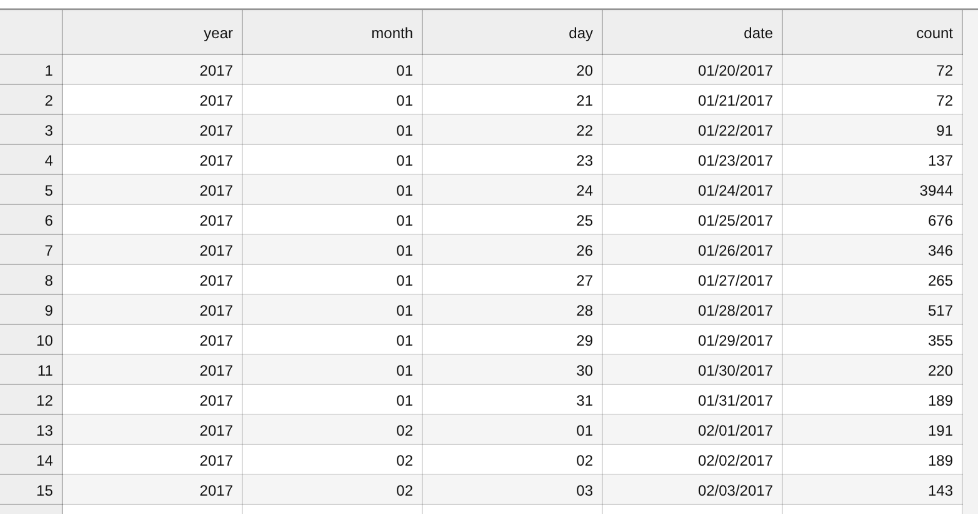{width=400}

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

### Load dataset

* Example time series for a search in tweet text for any occurrence of the sequence `oscars`
* Note this is too general a search but was used as an example to get a sample dataset

In [66]:
oscars_df = pd.read_csv('../data/example_twitter_timeline_OSCARS.csv')

* Convert the date `str` to a `datetime` object to facilitate date processing more easily in `pandas`

In [67]:
oscars_df['date_dt']=pd.to_datetime(oscars_df['date'], format='%m/%d/%Y')

### Some example plots

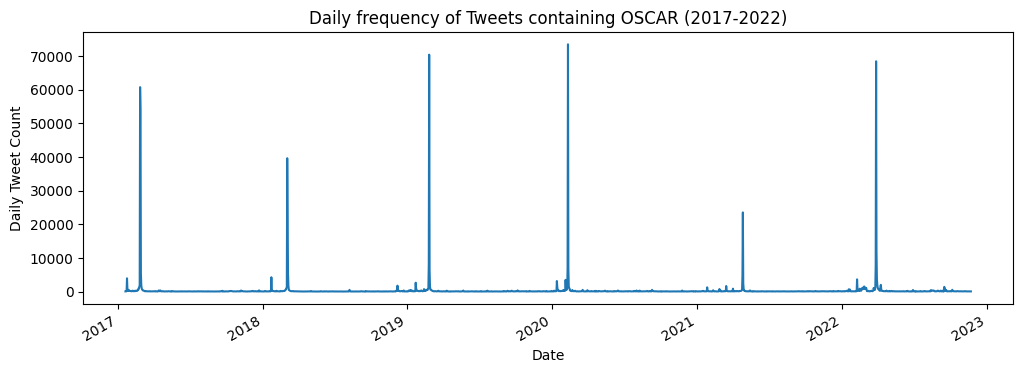

In [68]:
oscars_df.set_index('date_dt')['count'].plot(figsize=(12,4))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('Daily frequency of Tweets containing OSCAR (2017-2022)')
plt.show()

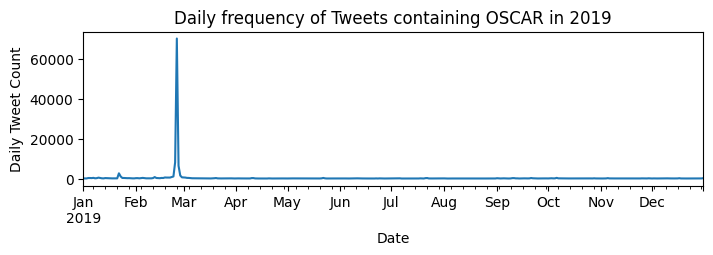

In [69]:
oscars_df.query('year==2019').set_index('date_dt')['count'].plot(figsize=(8,2))
plt.xlabel('Date')
plt.ylabel('Daily Tweet Count')
plt.title('Daily frequency of Tweets containing OSCAR in 2019')
plt.show()

In [70]:
oscars_df.query('year==2017 and month==2')

,year,month,day,date,count,date_dt
12,2017,2,1,02/01/2017,191,2017-02-01
13,2017,2,2,02/02/2017,189,2017-02-02
14,2017,2,3,02/03/2017,143,2017-02-03
15,2017,2,4,02/04/2017,111,2017-02-04
16,2017,2,5,02/05/2017,118,2017-02-05
17,2017,2,6,02/06/2017,195,2017-02-06
18,2017,2,7,02/07/2017,277,2017-02-07
19,2017,2,8,02/08/2017,145,2017-02-08
20,2017,2,9,02/09/2017,139,2017-02-09
21,2017,2,10,02/10/2017,212,2017-02-10


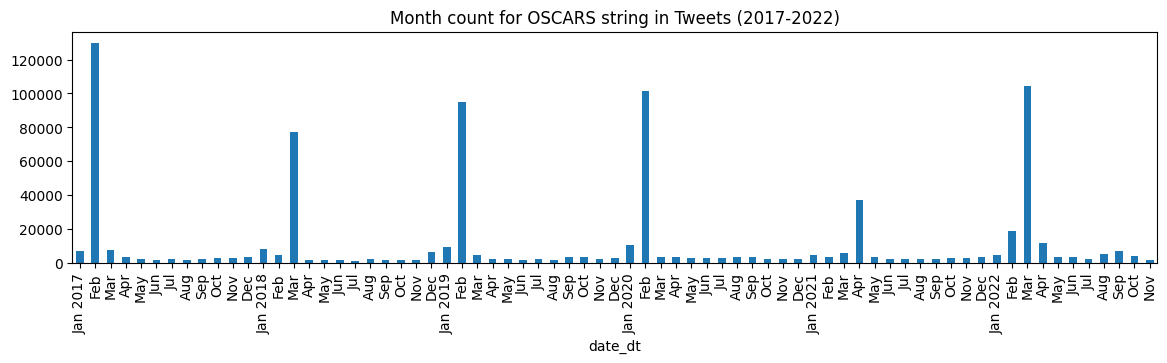

In [80]:
def line_format(label):
    """
    Convert time label to the format of pandas line plot
    """
    month = label.month_name()[:3]
    if month == 'Jan':
        month += f' {label.year}'
    return month


oscars_by_month = oscars_df.set_index('date_dt').resample('ME')['count'].sum()
    
ax=oscars_by_month.plot(kind='bar', figsize=(14,3))
ax.set_xticklabels(map(line_format, oscars_by_month.index))

plt.title('Month count for OSCARS string in Tweets (2017-2022)')
plt.show()


In [22]:
oscars_df.groupby(['year','month'])['count'].sum().reset_index()

,year,month,count
0,2017,1,6884
1,2017,2,130083
2,2017,3,7569
3,2017,4,3538
4,2017,5,2161
...,...,...,...
66,2022,7,2407
67,2022,8,4973
68,2022,9,6691
69,2022,10,3813
